# Dancing With The Stars: To The Top of the Leaderboard


# Introduction

Towards September through November, every Tuesday night at 8pm on ABC the popular television show Dancing with the Stars is shown. "Celebrities" like actors, athletes, comedians are paired with ballroom dancing "pros" where they perform chreographed dances live for the audience and once finished judges critique them and given a score 1-10. Additionally, viewers at home and in the audience vote for their favorite couple because at the end of each night one couple is eliminated until one couple is left and given the title as Mirrorball Champion. The question I want to explore is can I predict a celebrity's average dance score on Dancing with the Stars based on attributes such as their age, professional partner, industry background?

# The DataSet

The data set I chose is a file found from Kaggle: https://www.kaggle.com/datasets/brupley/dancing-with-the-stars-dataset?resource=download. It provides the competitors, scores, and results from seasons 1-32. 
    
    Personal attibutes include name, age during the season, home state/country, industry. 
    Competition details include professional dance partner, season number, final placement. 
    Performance data include weekly judges score from up to 11 weeks of competition. 
    Results include elimination status and final placement.


# Regrssion

Regressional is a statistical method used to model the relationship between a dependent variable (target) and one or more independent variables (features). Regarding the question I want to explore I'm using linear regression to predict weekly judges score on contestant attributes.

# Experiment 1: Data Understanding

The information I examined that was available about each contestant including their age, profession, which season they competed in, and most importantly their weekly judges score the visualizations I can make is a scatter plot showing how age relates to scores. By looking at the scatterplot where the X-axis shows a contestant's age during the season and the y-axis shows their average dance score, there is a slight tendency for younger contestants to score higher. 

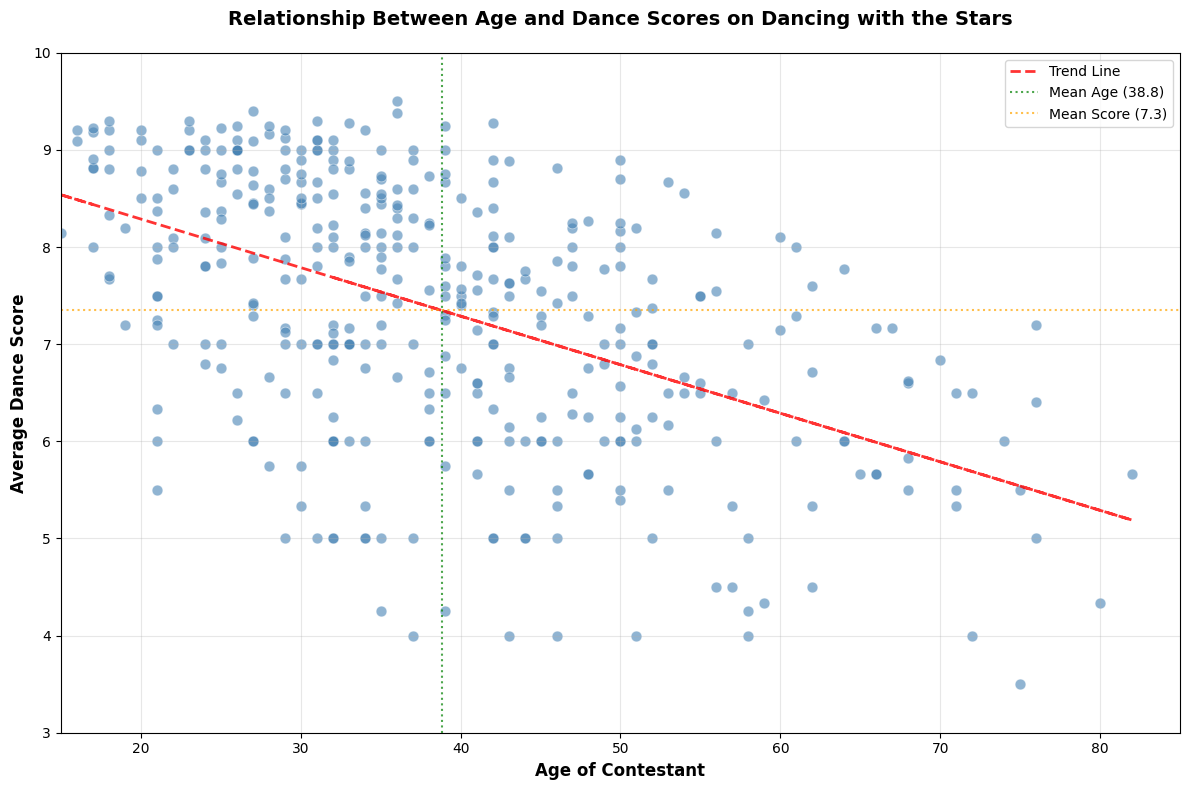

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load and prepare the data
df = pd.read_csv("../datasets/dancing_with_the_stars_dataset.csv")

# Calculate average score for each contestant
score_columns = [col for col in df.columns if 'week' in col and 'score' in col and 'avg' in col]

def calculate_average_score(row):
    scores = []
    for col in score_columns:
        if pd.notna(row[col]) and row[col] > 0:
            scores.append(row[col])
    return np.mean(scores) if scores else np.nan

df['average_score'] = df.apply(calculate_average_score, axis=1)
df_clean = df.dropna(subset=['average_score', 'celebrity_age_during_season']).copy()

# Create the scatter plot
plt.figure(figsize=(12, 8))

# Create scatter plot with enhanced styling
plt.scatter(df_clean['celebrity_age_during_season'], df_clean['average_score'], 
           alpha=0.6, color='steelblue', s=60, edgecolor='white', linewidth=0.5)

# Add trend line
z = np.polyfit(df_clean['celebrity_age_during_season'], df_clean['average_score'], 1)
p = np.poly1d(z)
plt.plot(df_clean['celebrity_age_during_season'], p(df_clean['celebrity_age_during_season']), 
         "r--", alpha=0.8, linewidth=2, label='Trend Line')

# Customize the plot
plt.xlabel('Age of Contestant', fontsize=12, fontweight='bold')
plt.ylabel('Average Dance Score', fontsize=12, fontweight='bold')
plt.title('Relationship Between Age and Dance Scores on Dancing with the Stars', 
          fontsize=14, fontweight='bold', pad=20)

# Add grid and styling
plt.grid(True, alpha=0.3)
plt.xlim(15, 85)
plt.ylim(3, 10)


# Add some statistics
mean_age = df_clean['celebrity_age_during_season'].mean()
mean_score = df_clean['average_score'].mean()
plt.axvline(mean_age, color='green', linestyle=':', alpha=0.7, label=f'Mean Age ({mean_age:.1f})')
plt.axhline(mean_score, color='orange', linestyle=':', alpha=0.7, label=f'Mean Score ({mean_score:.1f})')

plt.legend()
plt.tight_layout()
plt.show()



# Experiment 1: Pre Processing

After my initial understanding of the data, to deal with null values I should identify columns with significant missing data (the weekly scores for eliminated contestant) and the features I should trying using for my first experiment is the primary feature: celebrity_age_during_season and additional features to consider: celebrity_industry, and season. So, my target variable is creating an average score from available weekly scores. 

In [41]:
# EXPERIMENT 1: PRE-PROCESSING
print("EXPERIMENT 1: PRE-PROCESSING")
print("=" * 50)

# Load the dataset (using the provided data)
df = pd.read_csv("../datasets/dancing_with_the_stars_dataset.csv")

print("1. INITIAL DATA ASSESSMENT")
print("-" * 30)
print(f"Original dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

# Check for missing values in key columns
print(f"\nMissing values in key columns:")
print(f"Age: {df['celebrity_age_during_season'].isna().sum()}")
print(f"Industry: {df['celebrity_industry'].isna().sum()}")
print(f"Season: {df['season'].isna().sum()}")

# Handle missing values
print("\n2. HANDLING MISSING VALUES")
print("-" * 30)

# For age - we'll drop rows with missing age since it's our primary feature
df_clean = df.dropna(subset=['celebrity_age_during_season']).copy()
print(f"After dropping missing age: {len(df_clean)} contestants")

# For industry - fill missing with 'Unknown'
df_clean['celebrity_industry'] = df_clean['celebrity_industry'].fillna('Unknown')
print(f"Missing industries filled: {(df['celebrity_industry'].isna().sum())}")

# For weekly scores - we'll handle in the target variable creation

print("\n3. TARGET VARIABLE CREATION: AVERAGE SCORE")
print("-" * 30)

def calculate_robust_average_score(row):
    """
    Calculate average score from all available weekly judge scores
    Handles missing values and zero scores appropriately
    """
    scores = []
    
    # Check all judge score columns (individual judges and averages)
    for col in df.columns:
        if 'week' in col and 'score' in col:
            score_value = row[col]
            
            # Skip if missing, 'N/A', or zero
            if pd.isna(score_value) or score_value == 'N/A' or float(score_value) == 0:
                continue
                
            try:
                score_float = float(score_value)
                # Only include reasonable scores (between 1-10)
                if 1 <= score_float <= 10:
                    scores.append(score_float)
            except (ValueError, TypeError):
                continue
    
    # Return average if we have at least 2 scores, otherwise NaN
    return np.mean(scores) if len(scores) >= 2 else np.nan

# Apply the function to create target variable
df_clean['average_score'] = df_clean.apply(calculate_robust_average_score, axis=1)

print(f"Contestants with calculable average scores: {df_clean['average_score'].notna().sum()}")
print(f"Target variable range: {df_clean['average_score'].min():.2f} - {df_clean['average_score'].max():.2f}")

# Remove contestants without valid average scores
df_final = df_clean.dropna(subset=['average_score']).copy()
print(f"Final dataset size after pre-processing: {len(df_final)} contestants")

print("\n4. FEATURE SELECTION FOR EXPERIMENT 1")
print("-" * 30)

# Primary feature
primary_feature = 'celebrity_age_during_season'

# Additional features to consider
additional_features = ['celebrity_industry', 'season']

# Target variable
target_variable = 'average_score'

print(f"Primary feature: {primary_feature}")
print(f"Additional features: {additional_features}")
print(f"Target variable: {target_variable}")

print(f"\nSelected features for modeling:")
selected_features = [primary_feature] + additional_features
for feature in selected_features:
    unique_vals = df_final[feature].nunique()
    print(f"  - {feature}: {unique_vals} unique values")

# Handle categorical variable (industry)
print("Industry categories:")
industry_counts = df_final['celebrity_industry'].value_counts()
print(industry_counts)

# For linear regression, we'll need to encode categorical variables
# This will be done during modeling

print("\n5. FINAL PRE-PROCESSED DATASET")
print("-" * 30)
print(f"Final dataset shape: {df_final.shape}")
print(f"Features available: {list(df_final.columns)}")

# Display sample of the processed data
print(f"\nSample of pre-processed data:")
sample_cols = ['celebrity_name', 'celebrity_age_during_season', 'celebrity_industry', 'season', 'average_score']
print(df_final[sample_cols].head(10).to_string(index=False))

# Summary statistics
print(f"\nSummary statistics for modeling:")
print(f"Age range: {df_final['celebrity_age_during_season'].min()} - {df_final['celebrity_age_during_season'].max()}")
print(f"Average score range: {df_final['average_score'].min():.2f} - {df_final['average_score'].max():.2f}")
print(f"Seasons represented: {sorted(df_final['season'].unique())}")

# Check feature-target relationships
print(f"\nCorrelation between age and average score: {df_final['celebrity_age_during_season'].corr(df_final['average_score']):.3f}")

# Industry performance summary
print(f"\nAverage scores by industry:")
industry_performance = df_final.groupby('celebrity_industry')['average_score'].agg(['mean', 'count']).round(2)
print(industry_performance)


EXPERIMENT 1: PRE-PROCESSING
1. INITIAL DATA ASSESSMENT
------------------------------
Original dataset shape: (394, 75)
Columns: ['celebrity_name', 'ballroom_partner', 'celebrity_industry', 'celebrity_homestate', 'celebrity_homecountry', 'celebrity_age_during_season', 'season', 'week1_judge1_score', 'week1_judge2_score', 'week1_judge3_score', 'week1_judge4_score', 'week1_avg_judge_score', 'week1_total_judge_score', 'week2_judge1_score', 'week2_judge2_score', 'week2_judge3_score', 'week2_judge4_score', 'week2_avg_judge_score', 'week2_total_judge_score', 'week3_judge1_score', 'week3_judge2_score', 'week3_judge3_score', 'week3_judge4_score', 'week3_avg_judge_score', 'week3_total_judge_score', 'week4_judge1_score', 'week4_judge2_score', 'week4_judge3_score', 'week4_judge4_score', 'week4_avg_judge_score', 'week4_total_judge_score', 'week5_judge1_score', 'week5_judge2_score', 'week5_judge3_score', 'week5_judge4_score', 'week5_avg_judge_score', 'week5_total_judge_score', 'week6_judge1_score'

# Experiment 1: Modeling

EXPERIMENT 1: MODELING - Simple Linear Regression
1. SET UP FEATURES AND TARGET
------------------------------
Features: ['celebrity_age_during_season']
Target: average_score
X shape: (394, 1)
y shape: (394,)

2. CREATE AND TRAIN LINEAR REGRESSION MODEL
------------------------------
✓ Model trained successfully!
Model type: LinearRegression

3. EXTRACT MODEL COEFFICIENTS
------------------------------
Intercept (b0): 9.2225
Coefficient for Age (b1): -0.0488
Regression Equation: Score = 9.2225 + -0.0488 * Age

4. MAKE PREDICTIONS
------------------------------
Sample Predictions:
Age -> Actual Score -> Predicted Score
  32.0 -> 6.12 -> 7.66
  42.0 -> 5.00 -> 7.17
  35.0 -> 7.94 -> 7.51
  32.0 -> 7.08 -> 7.66
  50.0 -> 8.08 -> 6.78

5. EVALUATE MODEL PERFORMANCE
------------------------------
Mean Squared Error (MSE): 1.2765
Root Mean Squared Error (RMSE): 1.1298
R-squared (R²): 0.2604

6. VISUALIZE THE MODEL
------------------------------


/Users/jonathanjagdon/Documents/GitHub/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


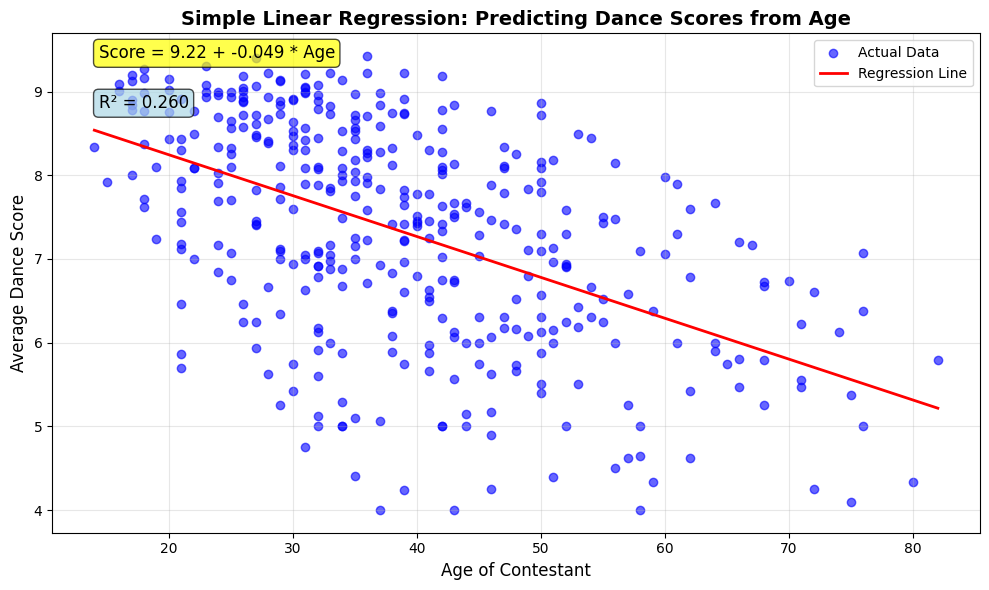

In [42]:
# EXPERIMENT 1: MODELING - Simple Linear Regression
print("EXPERIMENT 1: MODELING - Simple Linear Regression")
print("=" * 50)

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Load the pre-processed data
df = pd.read_csv('experiment1_processed_data.csv')

print("1. SET UP FEATURES AND TARGET")
print("-" * 30)

# Define target and features exactly as in pseudocode
target = 'average_score'
features = ['celebrity_age_during_season']

X = df[features]  # Feature matrix (only age)
y = df[target]    # Target vector (average scores)

print(f"Features: {features}")
print(f"Target: {target}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

print("\n2. CREATE AND TRAIN LINEAR REGRESSION MODEL")
print("-" * 30)

# Simple linear regression: Score = b0 + b1 * Age
model = LinearRegression()

# Train the model
model.fit(X, y)

print("✓ Model trained successfully!")
print(f"Model type: {type(model).__name__}")

print("\n3. EXTRACT MODEL COEFFICIENTS")
print("-" * 30)

# Get the coefficients
b0 = model.intercept_  # Intercept
b1 = model.coef_[0]   # Coefficient for age

print(f"Intercept (b0): {b0:.4f}")
print(f"Coefficient for Age (b1): {b1:.4f}")
print(f"Regression Equation: Score = {b0:.4f} + {b1:.4f} * Age")

print("\n4. MAKE PREDICTIONS")
print("-" * 30)

# Make predictions on the entire dataset
y_pred = model.predict(X)

# Display some example predictions
print("Sample Predictions:")
print("Age -> Actual Score -> Predicted Score")
for i in range(min(5, len(X))):
    age = X.iloc[i]['celebrity_age_during_season']
    actual = y.iloc[i]
    predicted = y_pred[i]
    print(f"  {age} -> {actual:.2f} -> {predicted:.2f}")

print("\n5. EVALUATE MODEL PERFORMANCE")
print("-" * 30)

# Calculate performance metrics
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")

print("\n6. VISUALIZE THE MODEL")
print("-" * 30)

# Create the visualization
plt.figure(figsize=(10, 6))

# Scatter plot of actual data
plt.scatter(X['celebrity_age_during_season'], y, alpha=0.6, color='blue', label='Actual Data')

# Regression line
x_range = np.linspace(X['celebrity_age_during_season'].min(), X['celebrity_age_during_season'].max(), 100)
y_range = model.predict(x_range.reshape(-1, 1))
plt.plot(x_range, y_range, color='red', linewidth=2, label='Regression Line')

# Customize the plot
plt.xlabel('Age of Contestant', fontsize=12)
plt.ylabel('Average Dance Score', fontsize=12)
plt.title('Simple Linear Regression: Predicting Dance Scores from Age', fontsize=14, fontweight='bold')

# Add the regression equation to the plot
equation = f'Score = {b0:.2f} + {b1:.3f} * Age'
plt.text(0.05, 0.95, equation, transform=plt.gca().transAxes, fontsize=12,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

# Add R-squared value
plt.text(0.05, 0.85, f'R² = {r2:.3f}', transform=plt.gca().transAxes, fontsize=12,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Experiment 1: Evaluation

EXPERIMENT 1: EVALUATION - Root Mean Squared Error
1. SET UP MODEL FOR EVALUATION
------------------------------
Training set: 275 samples
Testing set: 119 samples

2. TRAIN MODEL AND MAKE PREDICTIONS
------------------------------
✓ Model trained and predictions made

3. CALCULATE ROOT MEAN SQUARED ERROR (RMSE)
------------------------------
Training RMSE: 1.1645
Testing RMSE:  1.0538

Additional Metrics:
Training MSE:  1.3561
Testing MSE:   1.1105
Training R²:   0.2337
Testing R²:    0.2996
Training MAE:  0.9678
Testing MAE:   0.8350

4. INTERPRET RMSE RESULTS
------------------------------
What RMSE tells us:
• RMSE = 1.0538 means our predictions are typically within ±1.05 points of actual scores
• Since scores range from 4.0 to 9.4, this is a 19.4% error range
• The model explains 30.0% of the variance in dance scores


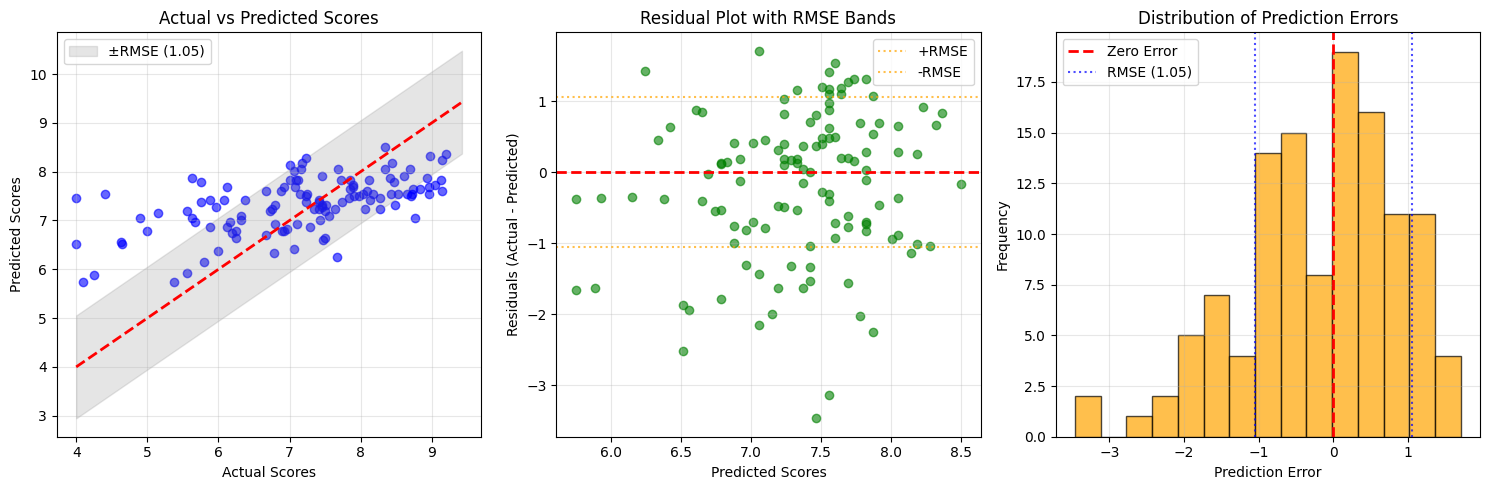

In [5]:
# EXPERIMENT 1: EVALUATION - Root Mean Squared Error
print("EXPERIMENT 1: EVALUATION - Root Mean Squared Error")
print("=" * 50)

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load the pre-processed data
df = pd.read_csv('experiment1_processed_data.csv')

print("1. SET UP MODEL FOR EVALUATION")
print("-" * 30)

# Define target and features
target = 'average_score'
features = ['celebrity_age_during_season']

X = df[features]
y = df[target]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set: {len(X_train)} samples")
print(f"Testing set: {len(X_test)} samples")

print("\n2. TRAIN MODEL AND MAKE PREDICTIONS")
print("-" * 30)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on both training and test sets
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print("✓ Model trained and predictions made")

print("\n3. CALCULATE ROOT MEAN SQUARED ERROR (RMSE)")
print("-" * 30)

# Calculate RMSE for both training and test sets
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"Training RMSE: {rmse_train:.4f}")
print(f"Testing RMSE:  {rmse_test:.4f}")

# Calculate additional metrics for comparison
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

print(f"\nAdditional Metrics:")
print(f"Training MSE:  {mse_train:.4f}")
print(f"Testing MSE:   {mse_test:.4f}")
print(f"Training R²:   {r2_train:.4f}")
print(f"Testing R²:    {r2_test:.4f}")
print(f"Training MAE:  {mae_train:.4f}")
print(f"Testing MAE:   {mae_test:.4f}")


print("\n4. INTERPRET RMSE RESULTS")
print("-" * 30)

print("What RMSE tells us:")
print(f"• RMSE = {rmse_test:.4f} means our predictions are typically within ±{rmse_test:.2f} points of actual scores")
print(f"• Since scores range from {y.min():.1f} to {y.max():.1f}, this is a {rmse_test/(y.max()-y.min())*100:.1f}% error range")
print(f"• The model explains {r2_test*100:.1f}% of the variance in dance scores")


# Create error analysis visualization
plt.figure(figsize=(15, 5))

# Plot 1: Actual vs Predicted with RMSE bands
plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred_test, alpha=0.6, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'red', linestyle='--', linewidth=2)
plt.xlabel('Actual Scores')
plt.ylabel('Predicted Scores')
plt.title('Actual vs Predicted Scores')
plt.grid(True, alpha=0.3)

# Add RMSE bands
plt.fill_between([y.min(), y.max()], [y.min()-rmse_test, y.max()-rmse_test], 
                 [y.min()+rmse_test, y.max()+rmse_test], alpha=0.2, color='gray', 
                 label=f'±RMSE ({rmse_test:.2f})')
plt.legend()

# Plot 2: Residuals (Errors)
plt.subplot(1, 3, 2)
residuals = y_test - y_pred_test
plt.scatter(y_pred_test, residuals, alpha=0.6, color='green')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.axhline(y=rmse_test, color='orange', linestyle=':', alpha=0.7, label=f'+RMSE')
plt.axhline(y=-rmse_test, color='orange', linestyle=':', alpha=0.7, label=f'-RMSE')
plt.xlabel('Predicted Scores')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot with RMSE Bands')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Error distribution
plt.subplot(1, 3, 3)
plt.hist(residuals, bins=15, alpha=0.7, color='orange', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
plt.axvline(x=rmse_test, color='blue', linestyle=':', alpha=0.7, label=f'RMSE ({rmse_test:.2f})')
plt.axvline(x=-rmse_test, color='blue', linestyle=':', alpha=0.7)
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Errors')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Experiment 2: Modeling

EXPERIMENT 2: MODELING - Professional Partner Feature
1. DATA PRE-PROCESSING FOR EXPERIMENT 2
------------------------------
Contestants with valid scores and partner data: 394
Number of unique professional partners: 51

Top 10 most frequent partners:
ballroom_partner
Cheryl Burke             25
Tony Dovolani            21
Mark Ballas              20
Valentin Chmerkovskiy    19
Karina Smirnoff          18
Maksim Chmerkoskiy       17
Derek Hough              17
Peta Murgatroyd          15
Emma Slater              15
Sharna Burgess           14
Name: count, dtype: int64

2. FEATURE ENGINEERING - PROFESSIONAL PARTNER
------------------------------
Primary feature: ballroom_partner
Target: average_score
X shape: (394, 1)
y shape: (394,)
Partners encoded: 51 unique partners

3. TRAIN MODEL WITH PARTNER FEATURE
------------------------------
Training set: 275 samples
Testing set: 119 samples
✓ Model trained with partner feature

4. ANALYZE PARTNER PERFORMANCE
------------------------------
T

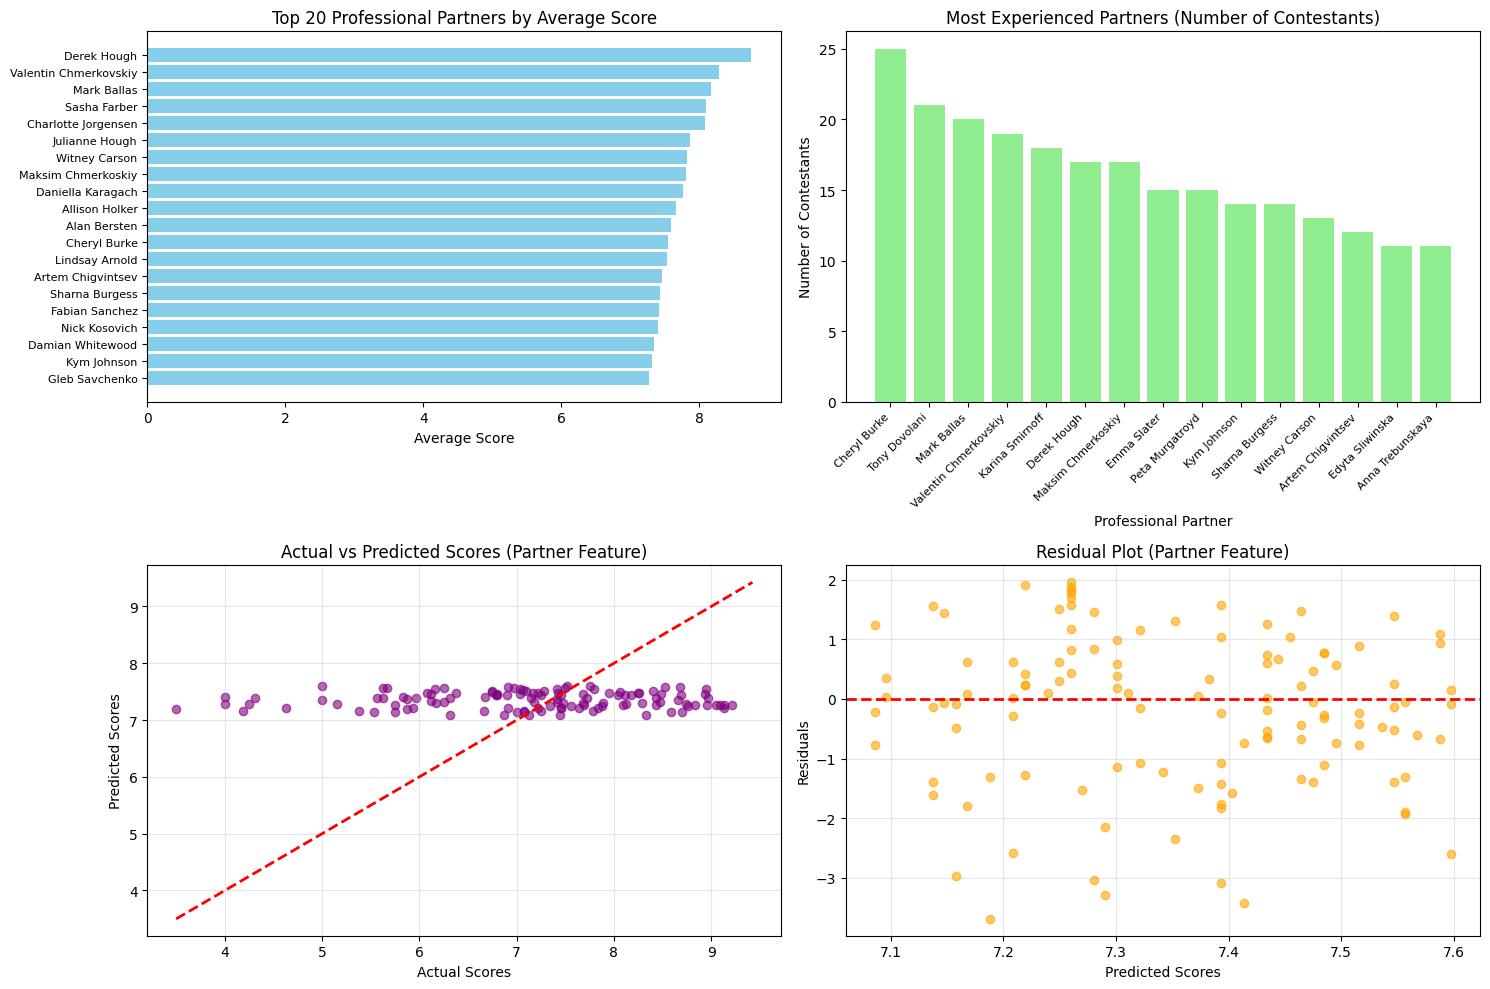

In [40]:
#EXPERIMENT 2: MODELING - Professional Partner as Feature
print("EXPERIMENT 2: MODELING - Professional Partner Feature")
print("=" * 50)

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

df = pd.read_csv("../datasets/dancing_with_the_stars_dataset.csv")

print("1. DATA PRE-PROCESSING FOR EXPERIMENT 2")
print("-" * 30)

# Calculate average score (same as Experiment 1)
def calculate_average_score(row):
    scores = []
    for col in df.columns:
        if 'week' in col and 'score' in col and ('judge1' in col or 'judge2' in col or 'judge3' in col or 'avg' in col):
            if pd.notna(row[col]) and row[col] != 'N/A' and float(row[col]) > 0:
                try:
                    scores.append(float(row[col]))
                except:
                    continue
    return np.mean(scores) if len(scores) >= 2 else np.nan

df['average_score'] = df.apply(calculate_average_score, axis=1)
df_clean = df.dropna(subset=['average_score', 'ballroom_partner']).copy()

print(f"Contestants with valid scores and partner data: {len(df_clean)}")

# Analyze professional partners
partner_counts = df_clean['ballroom_partner'].value_counts()
print(f"Number of unique professional partners: {len(partner_counts)}")
print(f"\nTop 10 most frequent partners:")
print(partner_counts.head(10))

print("\n2. FEATURE ENGINEERING - PROFESSIONAL PARTNER")
print("-" * 30)

# Use professional partner as the primary feature
target = 'average_score'
features = ['ballroom_partner']  # Changed from age to partner!

X = df_clean[features]
y = df_clean[target]

print(f"Primary feature: {features[0]}")
print(f"Target: {target}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Encode the categorical partner variable
le = LabelEncoder()
X_encoded = X.copy()
X_encoded['partner_encoded'] = le.fit_transform(X['ballroom_partner'])

print(f"Partners encoded: {len(le.classes_)} unique partners")

print("\n3. TRAIN MODEL WITH PARTNER FEATURE")
print("-" * 30)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded[['partner_encoded']], y, test_size=0.3, random_state=42
)

print(f"Training set: {len(X_train)} samples")
print(f"Testing set: {len(X_test)} samples")

# Train linear regression model
model_partner = LinearRegression()
model_partner.fit(X_train, y_train)

print("✓ Model trained with partner feature")

# Make predictions
y_pred_train = model_partner.predict(X_train)
y_pred_test = model_partner.predict(X_test)


print("\n4. ANALYZE PARTNER PERFORMANCE")
print("-" * 30)

# Calculate average scores by partner
partner_performance = df_clean.groupby('ballroom_partner').agg({
    'average_score': ['mean', 'count', 'std'],
    'placement': 'mean'
}).round(3)

partner_performance.columns = ['avg_score', 'num_contestants', 'score_std', 'avg_placement']
partner_performance = partner_performance.sort_values('avg_score', ascending=False)

print("Top 10 Professional Partners by Average Score:")
print(partner_performance.head(10))

print(f"\nBottom 10 Professional Partners by Average Score:")
print(partner_performance.tail(10))

plt.figure(figsize=(15, 10))

# Plot 1: Partner average scores (top 20)
plt.subplot(2, 2, 1)
top_partners = partner_performance.head(20)
plt.barh(range(len(top_partners)), top_partners['avg_score'], color='skyblue')
plt.yticks(range(len(top_partners)), top_partners.index, fontsize=8)
plt.xlabel('Average Score')
plt.title('Top 20 Professional Partners by Average Score')
plt.gca().invert_yaxis()

# Plot 2: Number of contestants per partner
plt.subplot(2, 2, 2)
partner_counts_plot = partner_performance['num_contestants'].sort_values(ascending=False).head(15)
plt.bar(range(len(partner_counts_plot)), partner_counts_plot, color='lightgreen')
plt.xticks(range(len(partner_counts_plot)), partner_counts_plot.index, rotation=45, ha='right', fontsize=8)
plt.xlabel('Professional Partner')
plt.ylabel('Number of Contestants')
plt.title('Most Experienced Partners (Number of Contestants)')

# Plot 3: Actual vs Predicted scores
plt.subplot(2, 2, 3)
plt.scatter(y_test, y_pred_test, alpha=0.6, color='purple')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'red', linestyle='--', linewidth=2)
plt.xlabel('Actual Scores')
plt.ylabel('Predicted Scores')
plt.title('Actual vs Predicted Scores (Partner Feature)')
plt.grid(True, alpha=0.3)

# Plot 4: Residuals
plt.subplot(2, 2, 4)
residuals = y_test - y_pred_test
plt.scatter(y_pred_test, residuals, alpha=0.6, color='orange')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Scores')
plt.ylabel('Residuals')
plt.title('Residual Plot (Partner Feature)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Experiment 2: Evaluation

In [37]:
print("\n1. EVALUATE MODEL PERFORMANCE")
print("-" * 30)

# Calculate RMSE and other metrics
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print(f"Training RMSE: {rmse_train:.4f}")
print(f"Testing RMSE:  {rmse_test:.4f}")
print(f"Training R²:   {r2_train:.4f}")
print(f"Testing R²:    {r2_test:.4f}")


print("\n2. KEY INSIGHTS FROM EXPERIMENT 2")
print("-" * 30)

# Analyze partner consistency
consistent_partners = partner_performance[partner_performance['num_contestants'] >= 3]
if len(consistent_partners) > 0:
    print("Partners with 3+ contestants (showing consistency):")
    print(consistent_partners[['avg_score', 'num_contestants', 'score_std']].sort_values('avg_score', ascending=False))

# Best and worst performing partners
best_partner = partner_performance.iloc[0]
worst_partner = partner_performance.iloc[-1]

print(f"\nBest Performing Partner:")
print(f"  {best_partner.name}: Average Score = {best_partner['avg_score']:.2f} ({best_partner['num_contestants']} contestants)")

print(f"Worst Performing Partner:")
print(f"  {worst_partner.name}: Average Score = {worst_partner['avg_score']:.2f} ({worst_partner['num_contestants']} contestants)")




1. EVALUATE MODEL PERFORMANCE
------------------------------
Training RMSE: 1.3163
Testing RMSE:  1.2967
Training R²:   0.0134
Testing R²:    -0.0309

2. KEY INSIGHTS FROM EXPERIMENT 2
------------------------------
Partners with 3+ contestants (showing consistency):
                       avg_score  num_contestants  score_std
ballroom_partner                                            
Derek Hough                8.752               17      0.415
Valentin Chmerkovskiy      8.282               19      0.850
Mark Ballas                8.174               20      1.012
Sasha Farber               8.093               11      0.496
Julianne Hough             7.869                5      1.164
Witney Carson              7.817               13      1.185
Maksim Chmerkoskiy         7.804               17      0.929
Daniella Karagach          7.761                4      0.793
Allison Holker             7.670                4      1.100
Alan Bersten               7.588                8      1.369

# Experiment 3: Modeling 

EXPERIMENT 3: MODELING - Celebrity Industry Feature
1. DATA PRE-PROCESSING FOR EXPERIMENT 3
------------------------------
Contestants with valid scores and industry data: 394
Number of unique industries: 23

Industry distribution:
celebrity_industry
Actor/Actress               121
Athlete                      89
TV Personality               61
Singer/Rapper                59
Model                        16
Comedian                     11
Social Media Personality      8
Racing Driver                 4
Radio Personality             4
News Anchor                   3
Entrepreneur                  3
Politician                    3
Sports Broadcaster            2
Military                      1
Producer                      1
Musician                      1
Journalist                    1
Astronaut                     1
Motivational Speaker          1
Fashion Designer              1
Beauty Pagent                 1
Magician                      1
Fitness Instructor            1
Name: count, 

/var/folders/l9/70smnm5938z_dx4_7tr0tn8w0000gn/T/ipykernel_50694/2548802408.py:166: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=top_industry_data, x='average_score', y=feature, palette='viridis')


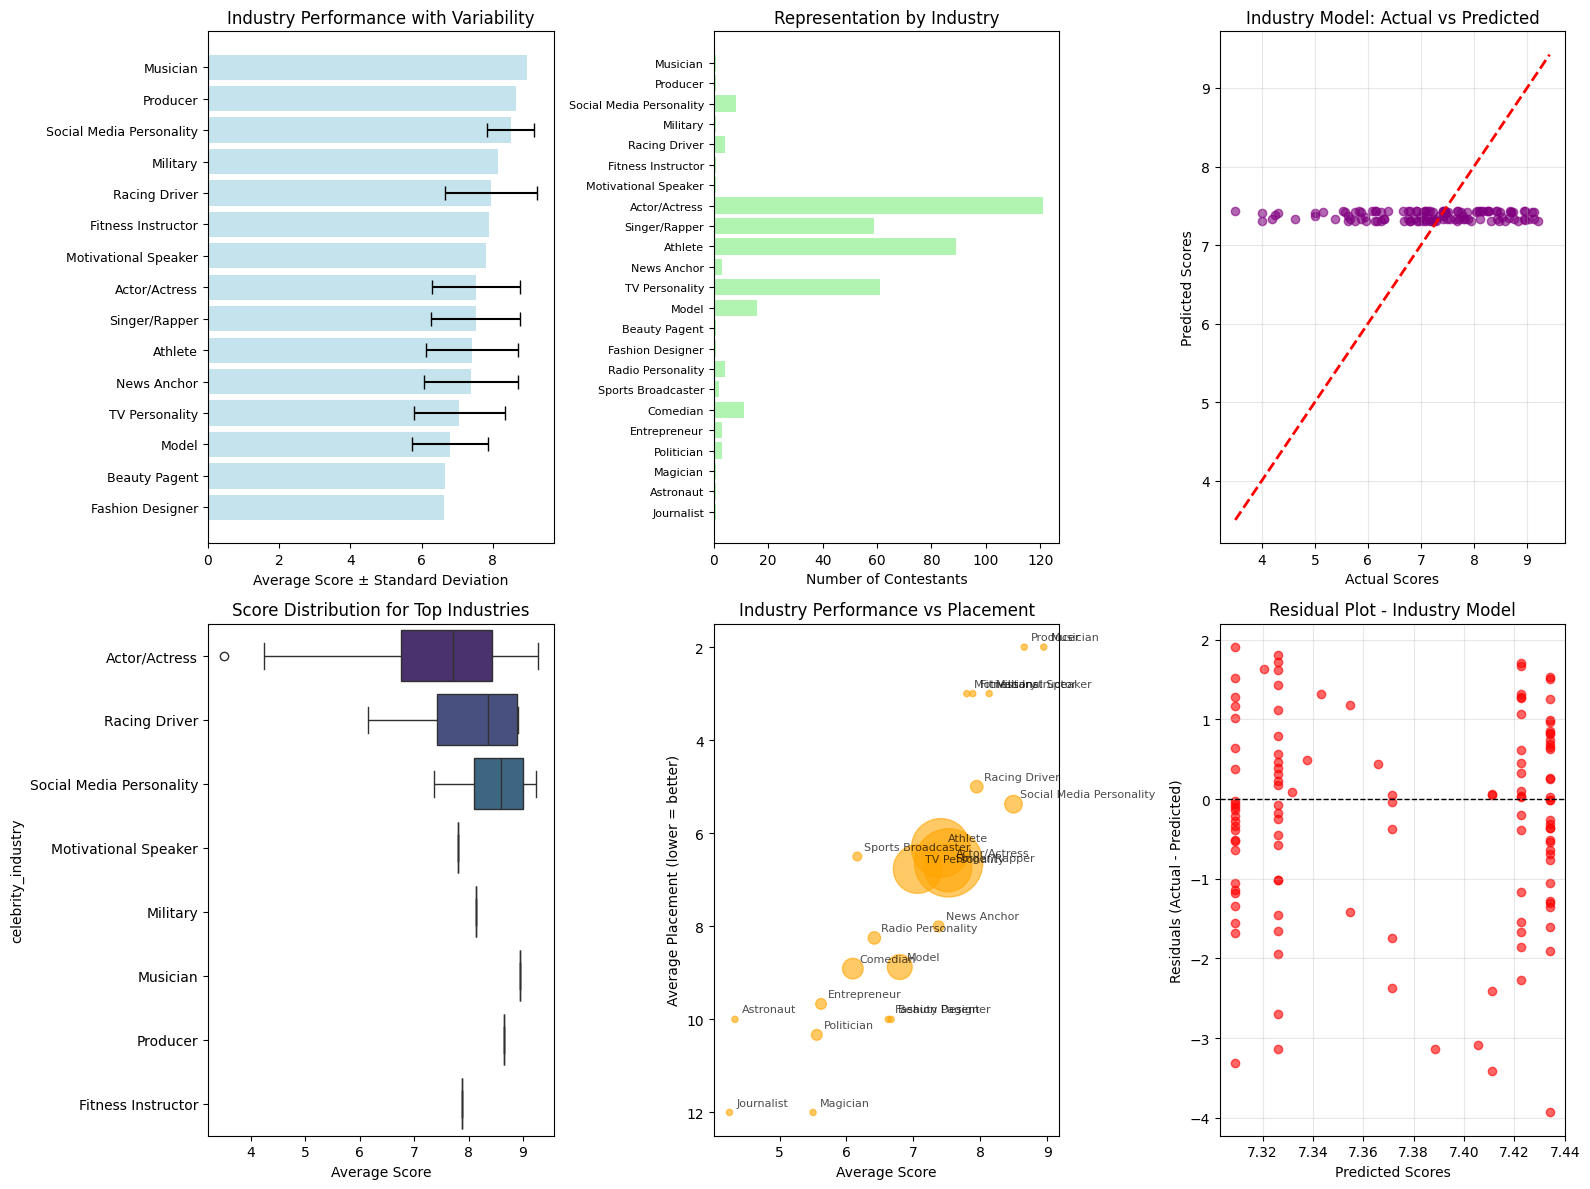


7. KEY INSIGHTS FROM EXPERIMENT 3
------------------------------
BEST PERFORMING INDUSTRY:
  Musician
  Average Score: 8.95
  Contestants: 1.0
  Best Placement: 2.0

WORST PERFORMING INDUSTRY:
  Journalist
  Average Score: 4.25
  Contestants: 1.0
  Average Placement: 12.0

PERFORMANCE RANGE:
  Scores: 4.25 - 8.95
  Spread: 4.70 points


In [39]:
# EXPERIMENT 3: MODELING - Celebrity Industry as Feature
print("EXPERIMENT 3: MODELING - Celebrity Industry Feature")
print("=" * 50)

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('../datasets/dancing_with_the_stars_dataset.csv')

print("1. DATA PRE-PROCESSING FOR EXPERIMENT 3")
print("-" * 30)

# Calculate average score
def calculate_average_score(row):
    scores = []
    for col in df.columns:
        if 'week' in col and 'score' in col and ('judge1' in col or 'judge2' in col or 'judge3' in col or 'avg' in col):
            if pd.notna(row[col]) and row[col] != 'N/A':
                try:
                    score_val = float(row[col])
                    if score_val > 0:
                        scores.append(score_val)
                except (ValueError, TypeError):
                    continue
    return np.mean(scores) if len(scores) >= 2 else np.nan

df['average_score'] = df.apply(calculate_average_score, axis=1)

# Use celebrity_industry as the primary feature
target = 'average_score'
feature = 'celebrity_industry'

df_clean = df.dropna(subset=['average_score', feature]).copy()
print(f"Contestants with valid scores and industry data: {len(df_clean)}")

# Analyze industries
industry_counts = df_clean[feature].value_counts()
print(f"Number of unique industries: {len(industry_counts)}")
print(f"\nIndustry distribution:")
print(industry_counts)

print("\n2. FEATURE ENGINEERING - INDUSTRY ANALYSIS")
print("-" * 30)

X = df_clean[[feature]]
y = df_clean[target]

print(f"Primary feature: {feature}")
print(f"Target: {target}")

# Encode the industry feature
le = LabelEncoder()
X_encoded = X.copy()
X_encoded['industry_encoded'] = le.fit_transform(X[feature])

print(f"Industries encoded: {len(le.classes_)}")
print(f"All industries: {list(le.classes_)}")

print("\n3. TRAIN MODEL WITH INDUSTRY FEATURE")
print("-" * 30)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded[['industry_encoded']], y, test_size=0.3, random_state=42
)

print(f"Training set: {len(X_train)} samples")
print(f"Testing set: {len(X_test)} samples")

# Train linear regression model
model_industry = LinearRegression()
model_industry.fit(X_train, y_train)

print("✓ Model trained with industry feature")

# Make predictions
y_pred_train = model_industry.predict(X_train)
y_pred_test = model_industry.predict(X_test)

print("\n4. EVALUATE MODEL PERFORMANCE")
print("-" * 30)

# Calculate RMSE and other metrics
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)

print(f"Training RMSE: {rmse_train:.4f}")
print(f"Testing RMSE:  {rmse_test:.4f}")
print(f"Training R²:   {r2_train:.4f}")
print(f"Testing R²:    {r2_test:.4f}")
print(f"Testing MAE:   {mae_test:.4f}")

print("\n5. DETAILED INDUSTRY PERFORMANCE ANALYSIS")
print("-" * 30)

# Calculate comprehensive industry statistics
industry_performance = df_clean.groupby(feature).agg({
    'average_score': ['mean', 'median', 'std', 'count', 'min', 'max'],
    'placement': ['mean', 'min'],
    'celebrity_age_during_season': 'mean'
}).round(3)

industry_performance.columns = [
    'avg_score', 'median_score', 'score_std', 'num_contestants', 
    'min_score', 'max_score', 'avg_placement', 'best_placement', 'avg_age'
]

industry_performance = industry_performance.sort_values('avg_score', ascending=False)

print("Industry Performance Ranking:")
print(industry_performance)

# Analyze industries with multiple contestants for reliability
reliable_industries = industry_performance[industry_performance['num_contestants'] >= 3]
print(f"\nIndustries with 3+ contestants (more reliable):")
print(reliable_industries[['avg_score', 'num_contestants', 'score_std']])

print("\n6. VISUALIZE INDUSTRY PERFORMANCE")
print("-" * 30)

plt.figure(figsize=(16, 12))

# Plot 1: Industry average scores with confidence intervals
plt.subplot(2, 3, 1)
industries_plot = industry_performance.head(15)  # Top 15 industries
y_pos = np.arange(len(industries_plot))
plt.barh(y_pos, industries_plot['avg_score'], xerr=industries_plot['score_std'], 
         color='lightblue', alpha=0.7, capsize=5)
plt.yticks(y_pos, industries_plot.index, fontsize=9)
plt.xlabel('Average Score ± Standard Deviation')
plt.title('Industry Performance with Variability')
plt.gca().invert_yaxis()

# Plot 2: Number of contestants per industry
plt.subplot(2, 3, 2)
plt.barh(range(len(industry_performance)), industry_performance['num_contestants'], 
         color='lightgreen', alpha=0.7)
plt.yticks(range(len(industry_performance)), industry_performance.index, fontsize=8)
plt.xlabel('Number of Contestants')
plt.title('Representation by Industry')
plt.gca().invert_yaxis()

# Plot 3: Actual vs Predicted scores
plt.subplot(2, 3, 3)
plt.scatter(y_test, y_pred_test, alpha=0.6, color='purple')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'red', linestyle='--', linewidth=2)
plt.xlabel('Actual Scores')
plt.ylabel('Predicted Scores')
plt.title('Industry Model: Actual vs Predicted')
plt.grid(True, alpha=0.3)

# Plot 4: Box plot of scores by industry (top 8)
plt.subplot(2, 3, 4)
top_industries = industry_performance.head(8).index
top_industry_data = df_clean[df_clean[feature].isin(top_industries)]
sns.boxplot(data=top_industry_data, x='average_score', y=feature, palette='viridis')
plt.xlabel('Average Score')
plt.title('Score Distribution for Top Industries')

# Plot 5: Industry vs Placement
plt.subplot(2, 3, 5)
plt.scatter(industry_performance['avg_score'], industry_performance['avg_placement'], 
           s=industry_performance['num_contestants']*20, alpha=0.6, color='orange')
plt.xlabel('Average Score')
plt.ylabel('Average Placement (lower = better)')
plt.title('Industry Performance vs Placement')
plt.gca().invert_yaxis()  # Lower placement numbers are better

# Add industry labels to the plot
for i, industry in enumerate(industry_performance.index):
    plt.annotate(industry, 
                (industry_performance['avg_score'].iloc[i], industry_performance['avg_placement'].iloc[i]),
                xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

# Plot 6: Residual analysis
plt.subplot(2, 3, 6)
residuals = y_test - y_pred_test
plt.scatter(y_pred_test, residuals, alpha=0.6, color='red')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Predicted Scores')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot - Industry Model')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n7. KEY INSIGHTS FROM EXPERIMENT 3")
print("-" * 30)

# Best and worst performing industries
best_industry = industry_performance.iloc[0]
worst_industry = industry_performance.iloc[-1]

print(f"BEST PERFORMING INDUSTRY:")
print(f"  {best_industry.name}")
print(f"  Average Score: {best_industry['avg_score']:.2f}")
print(f"  Contestants: {best_industry['num_contestants']}")
print(f"  Best Placement: {best_industry['best_placement']:.1f}")

print(f"\nWORST PERFORMING INDUSTRY:")
print(f"  {worst_industry.name}")
print(f"  Average Score: {worst_industry['avg_score']:.2f}")
print(f"  Contestants: {worst_industry['num_contestants']}")
print(f"  Average Placement: {worst_industry['avg_placement']:.1f}")

print(f"\nPERFORMANCE RANGE:")
print(f"  Scores: {worst_industry['avg_score']:.2f} - {best_industry['avg_score']:.2f}")
print(f"  Spread: {best_industry['avg_score'] - worst_industry['avg_score']:.2f} points")




# Experiment 3: Evaluation

In [35]:
print("\n1. TRAIN MODEL WITH INDUSTRY FEATURE")
print("-" * 30)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded[['industry_encoded']], y, test_size=0.3, random_state=42
)

print(f"Training set: {len(X_train)} samples")
print(f"Testing set: {len(X_test)} samples")

# Train linear regression model
model_industry = LinearRegression()
model_industry.fit(X_train, y_train)

print("✓ Model trained with industry feature")

# Make predictions
y_pred_train = model_industry.predict(X_train)
y_pred_test = model_industry.predict(X_test)

print("\n2. EVALUATE MODEL PERFORMANCE")
print("-" * 30)

# Calculate RMSE and other metrics
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)

print(f"Training RMSE: {rmse_train:.4f}")
print(f"Testing RMSE:  {rmse_test:.4f}")
print(f"Training R²:   {r2_train:.4f}")
print(f"Testing R²:    {r2_test:.4f}")
print(f"Testing MAE:   {mae_test:.4f}")


1. TRAIN MODEL WITH INDUSTRY FEATURE
------------------------------
Training set: 275 samples
Testing set: 119 samples
✓ Model trained with industry feature

2. EVALUATE MODEL PERFORMANCE
------------------------------
Training RMSE: 1.3242
Testing RMSE:  1.2972
Training R²:   0.0015
Testing R²:    -0.0317
Testing MAE:   0.9969


# Impact Section

Regarding the social impacts of my project, it can help with enhancing the viewer experience. As a viewer, the pros aren't just teachers but as a coach, chreographer, and strategist to the celebrity. The pros can choreograph dances designed to hide the celebrity's weakness and showcase their strength in hopes of getting a high score by the judges and being saved from elimination. Dancing with the Stars is about journey where celebrities may be a nervous performer in Week 1 to a confident performer if they make it to the finale. This allows viewers to invest in the personal growth of each celebrity and the success in the pro and celebrity partnership. Additionally, the viewer becomes an active critic in which if their favorite pair gets severely underscored then they voice their disapproval online through social media apps like X, Instagram, and Tiktok. This generates more engagement as a viewer. 

    

# Conclusion

What I've learned from this project and through the different experiments is that depending on the age of the celebrity then their average weekly score is slightly affected. Looking at the scatterplot under Experiment 1: Data Understanding that the celebrity ages 20-30, their average dance score were between 8-9 while if the celebrity ages 60-70 their average dance score were between 5-6. But, their average weekly score can also be slightly affected with the professional ballroom partner they're paired with. Looking at the bar chart under Experiment 2: Modeling and professional ballroom partner, Derek Hough has an average score close to 10. This implies he has a lot of experience, as he is a 6x Mirrorball Champion, and now a judge on the show. When I did Experiment 3, the average weekly score is also slightly affected by the industry their in. Musicians may naturally perform better as they can count the beats of the song and being in sync with their ballroom partner. Though it's bias since looking at the Industry Performance Ranking there has only been 1 musician on the show and has the highest average score compared to multiple contestants in the actoss/actress, athlete, and tv personality industry and their highest average score is in the middle.
